# v02 — Signal Research & Backtest: XAUUSD M5

**Tujuan versi ini:**
1. Generate sinyal BUY/SELL/WAIT dari dataset v01 (`app.utils.signals.generate_signal` — scoring gabungan ala quant-trader-ai)
2. Simulasi backtest candle-by-candle: entry saat ada sinyal, cek TP/SL, hitung PnL riil
3. Position sizing berbasis **risk % modal per trade** (bukan fixed lot), supaya konsisten dgn manajemen risiko
4. Evaluasi: win rate, profit factor, max drawdown, PnL harian, equity curve — **apa adanya**, termasuk kalau hasil belum capai target

**Asumsi & parameter modal:**
- Modal awal: **$100**
- Risk per trade: **1% equity** (~$1 saat modal $100) — bukan 10%, supaya rangkaian loss beruntun tidak menghabiskan modal
- Target: profit harian ~10% ($10) — ini target agregat dari BANYAK trade kecil per hari (scalping), bukan dari 1 trade besar
- Kontrak XAUUSD: 1 lot = 100 oz, pergerakan harga $1 = $100 per 1.0 lot
- TP/SL fixed pips (poin harga), disesuaikan lewat parameter `TP_POINTS` / `SL_POINTS` di bawah

**PENTING — catatan kejujuran hasil:** backtest ini akan melaporkan hasil apa adanya. Target "profit
tiap hari tanpa loss" TIDAK realistis untuk strategi apa pun — yang dievaluasi adalah **profitability
dalam agregat** (win rate, expectancy, profit factor) meskipun ada hari/trade yang rugi. Hasil versi
ini adalah baseline untuk dituning di versi berikutnya (v03, v04, dst), bukan hasil final.

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent.parent
sys.path.append(str(PROJECT_ROOT))

import math

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from app.utils.signals import generate_signal, Signal

STRATEGY_NAME = "m5_scalping"
VERSION = "v02"

PROCESSED_DIR = PROJECT_ROOT / "dataset" / "processed" / STRATEGY_NAME
EXPORT_DIR = PROJECT_ROOT / "dataset" / "exports" / STRATEGY_NAME / VERSION
EXPORT_DIR.mkdir(parents=True, exist_ok=True)

pd.set_option("display.width", 140)
plt.rcParams["figure.figsize"] = (14, 5)

## 1. Load dataset v01 (M5 + indikator)

In [2]:
df = pd.read_csv(PROCESSED_DIR / "v01" / "xauusd_m5_full_indicators.csv")
df["datetime"] = pd.to_datetime(df["datetime"])
df = df.sort_values("datetime").reset_index(drop=True)

print(df.shape, df["datetime"].min(), "->", df["datetime"].max())
df.tail(3)

(518403, 75) 2019-01-01 23:00:00+00:00 -> 2026-08-06 12:35:00+00:00


,timestamp,datetime,open,high,low,close,volume,ema_9,ema_20,ema_50,...,ob_bull,ob_bear,bos_bull,bos_bear,choch_bull,choch_bear,liq_bull_sweep,liq_bear_sweep,candle_pat,candle_ex
518400,1786019100000,2026-08-06 12:25:00+00:00,4260.685,4261.635,4256.535,4261.595,0.0804,4260.124171,4262.330420,4265.333070,...,0,0,0,0,0,0,0,0,1,2
518401,1786019400000,2026-08-06 12:30:00+00:00,4261.885,4269.755,4257.925,4267.565,0.1259,4261.612337,4262.828952,4265.420597,...,0,0,0,0,0,0,0,0,0,2
518402,1786019700000,2026-08-06 12:35:00+00:00,4267.805,4270.565,4266.935,4269.235,0.1002,4263.136869,4263.439052,4265.570181,...,0,0,0,0,0,0,0,0,0,2


## 1b. Load dataset H1 (+ indikator) sebagai konteks trend

H1 dipakai sebagai konteks/filter trend (bukan basis entry) — sama seperti pendekatan quant-trader-ai.
Untuk tiap candle M5, kita ambil **candle H1 terakhir yang sudah closed** sebelum waktu M5 tsb
(`merge_asof` dengan `direction="backward"`) supaya tidak ada data leakage (tidak mengintip H1 yang
belum selesai terbentuk) — realistis untuk kondisi live trading.

In [3]:
df_h1 = pd.read_csv(PROCESSED_DIR / "v01" / "xauusd_h1_full_indicators.csv")
df_h1["datetime"] = pd.to_datetime(df_h1["datetime"])
df_h1 = df_h1.sort_values("datetime").reset_index(drop=True)

# H1 "closed" berarti candle itu baru bisa dipakai SETELAH datetime+1jam (waktu candle berikutnya mulai).
# Geser timestamp H1 maju 1 jam supaya merge_asof(backward) otomatis hanya match candle yg sudah closed.
df_h1_shifted = df_h1.copy()
df_h1_shifted["h1_available_at"] = df_h1_shifted["datetime"] + pd.Timedelta(hours=1)

# Prefix semua kolom H1 (kecuali kunci join) supaya tidak bentrok nama dengan kolom M5
h1_value_cols = [c for c in df_h1_shifted.columns if c not in ("h1_available_at",)]
df_h1_shifted = df_h1_shifted[["h1_available_at", *h1_value_cols]].rename(
    columns={c: f"h1_{c}" for c in h1_value_cols}
)

print("H1 shifted shape:", df_h1_shifted.shape)
df_h1_shifted.tail(3)

H1 shifted shape: (44809, 76)


,h1_available_at,h1_timestamp,h1_datetime,h1_open,h1_high,h1_low,h1_close,h1_volume,h1_ema_9,h1_ema_20,...,h1_ob_bull,h1_ob_bear,h1_bos_bull,h1_bos_bear,h1_choch_bull,h1_choch_bear,h1_liq_bull_sweep,h1_liq_bear_sweep,h1_candle_pat,h1_candle_ex
44806,2026-08-06 10:00:00+00:00,1786006800000,2026-08-06 09:00:00+00:00,4278.055,4284.555,4270.975,4272.735,1.1007,4267.093824,4247.406502,...,0,0,0,0,0,0,0,0,0,-1
44807,2026-08-06 11:00:00+00:00,1786010400000,2026-08-06 10:00:00+00:00,4272.735,4273.295,4264.245,4270.635,0.9026,4267.802059,4249.618740,...,0,0,0,0,0,0,0,0,0,0
44808,2026-08-06 12:00:00+00:00,1786014000000,2026-08-06 11:00:00+00:00,4270.645,4273.305,4253.905,4263.205,1.2657,4266.882647,4250.912670,...,0,0,0,0,0,0,0,0,0,-2


In [4]:
# Gabungkan M5 dengan H1 closed candle terakhir (as-of backward join)
df = pd.merge_asof(
    df.sort_values("datetime"),
    df_h1_shifted.sort_values("h1_available_at"),
    left_on="datetime",
    right_on="h1_available_at",
    direction="backward",
)

print("M5 + konteks H1:", df.shape)
print("Baris tanpa H1 tersedia (awal data, wajar sedikit):", df["h1_close"].isna().sum())
df[["datetime", "close", "h1_datetime", "h1_close", "h1_adx", "h1_ema_50"]].tail(5)

M5 + konteks H1: (518403, 151)
Baris tanpa H1 tersedia (awal data, wajar sedikit): 12


,datetime,close,h1_datetime,h1_close,h1_adx,h1_ema_50
518398,2026-08-06 12:15:00+00:00,4256.925,2026-08-06 11:00:00+00:00,4263.205,55.226331,4195.341177
518399,2026-08-06 12:20:00+00:00,4260.645,2026-08-06 11:00:00+00:00,4263.205,55.226331,4195.341177
518400,2026-08-06 12:25:00+00:00,4261.595,2026-08-06 11:00:00+00:00,4263.205,55.226331,4195.341177
518401,2026-08-06 12:30:00+00:00,4267.565,2026-08-06 11:00:00+00:00,4263.205,55.226331,4195.341177
518402,2026-08-06 12:35:00+00:00,4269.235,2026-08-06 11:00:00+00:00,4263.205,55.226331,4195.341177


## 2. Generate sinyal untuk tiap candle

Catatan performa: `generate_signal` jalan per-baris (bukan vectorized) supaya scoring-nya mudah dibaca
& di-debug. Untuk ~518K baris ini bisa makan waktu — kita batasi ke rentang tertentu dulu untuk iterasi
cepat, baru jalankan full dataset setelah parameter sudah cukup meyakinkan.

In [5]:
# Mulai dari subset (1 tahun terakhir) dulu untuk iterasi cepat.
# Ganti ke df penuh setelah parameter (MIN_SIGNAL_SCORE dkk) sudah oke.
BACKTEST_START = "2025-01-01"
df_bt = df[df["datetime"] >= BACKTEST_START].reset_index(drop=True)
print("Baris untuk backtest:", len(df_bt))

Baris untuk backtest: 107336


In [6]:
MIN_SIGNAL_SCORE = 6.0
ADX_MIN = 18.0
ATR_MIN_PCT = 0.03

directions = np.empty(len(df_bt), dtype=object)
scores = np.zeros(len(df_bt))

for pos, (_, row) in enumerate(df_bt.iterrows()):
    result = generate_signal(row, MIN_SIGNAL_SCORE, ADX_MIN, ATR_MIN_PCT)
    directions[pos] = result.direction
    scores[pos] = result.final_score

df_bt["signal_direction"] = directions
df_bt["signal_score"] = scores

df_bt["signal_direction"].value_counts()

signal_direction
WAIT    79198
BUY     14513
SELL    13625
Name: count, dtype: int64

## 3. Simulasi backtest candle-by-candle

Aturan simulasi:
- Hanya 1 posisi terbuka dalam satu waktu (tidak overlap)
- Entry di `close` candle saat sinyal muncul, TP/SL fixed poin dari entry
- Cek candle berikutnya satu-satu: kalau `low<=SL` dan `high>=TP` di candle yang sama, asumsikan
  **SL kena duluan** (asumsi konservatif — worst case, supaya backtest tidak terlalu optimis)
- Kalau tidak kena TP/SL sampai `MAX_HOLD_CANDLES`, tutup di `close` candle terakhir (timeout)
- Lot size dihitung dari `RISK_PCT * equity` dibagi jarak SL (position sizing dinamis, ikut equity naik/turun)

**Log per-trade:** tiap trade menyimpan snapshot LENGKAP semua kolom indikator M5 (`ind_*`, termasuk
`ind_candle_pat`/`ind_candle_ex` — tipe pola candle) **dan** semua kolom H1 (`ind_h1_*`, candle H1
terakhir yang sudah closed saat itu — OHLC + seluruh indikatornya) saat candle entry, plus hasil
(exit price, PnL, equity) — supaya bisa dievaluasi manual nanti: kondisi market M5 & H1 seperti apa
yang menghasilkan win vs loss.

In [7]:
INITIAL_EQUITY = 100.0
RISK_PCT = 0.01          # 1% equity per trade
TP_POINTS = 12.0         # target profit dalam poin harga XAUUSD (mis. 2650.00 -> 2662.00)
SL_POINTS = 6.0          # stop loss dalam poin harga (RR 1:2)
MAX_HOLD_CANDLES = 24    # 24 x M5 = 2 jam, timeout kalau belum kena TP/SL
CONTRACT_SIZE = 100.0    # 1 lot = 100 oz, $1 pergerakan harga = $100/lot
MIN_LOT = 0.01
LOT_STEP = 0.01
SPREAD_POINTS = 0.30     # asumsi spread rata-rata XAUUSD (poin), dikurangi dari tiap entry sbg biaya

In [8]:
def calc_lot(equity: float, risk_pct: float, sl_distance: float) -> float:
    if sl_distance <= 0 or equity <= 0:
        return MIN_LOT
    risk_amount = equity * risk_pct
    raw_lot = risk_amount / (sl_distance * CONTRACT_SIZE)
    lot = math.floor(raw_lot / LOT_STEP) * LOT_STEP
    return max(round(lot, 2), MIN_LOT)


# Kolom indikator M5 + H1 yang di-snapshot penuh ke log (semua kolom df_bt kecuali kolom
# waktu/hasil sinyal yang sudah ada representasinya sendiri di trade record).
# CATATAN: open/high/low/close/volume M5 SENGAJA DIIKUTKAN (prefix ind_) di sini supaya
# harga OHLC M5 mentah saat entry eksplisit tercatat, bukan cuma entry_price.
INDICATOR_COLUMNS = [
    c for c in df_bt.columns
    if c not in ("timestamp", "datetime", "signal_direction", "signal_score")
]


def run_backtest(df_signals: pd.DataFrame) -> tuple[pd.DataFrame, list[float]]:
    trades = []
    equity = INITIAL_EQUITY
    equity_curve = [equity]
    i = 0
    n = len(df_signals)

    while i < n:
        row = df_signals.iloc[i]
        direction = row["signal_direction"]

        if direction == "WAIT":
            i += 1
            continue

        entry_price = row["close"] + (SPREAD_POINTS if direction == "BUY" else -SPREAD_POINTS)
        entry_time = row["datetime"]

        if direction == "BUY":
            tp_price = entry_price + TP_POINTS
            sl_price = entry_price - SL_POINTS
        else:
            tp_price = entry_price - TP_POINTS
            sl_price = entry_price + SL_POINTS

        lot = calc_lot(equity, RISK_PCT, SL_POINTS)
        equity_before = equity

        exit_price = None
        exit_time = None
        exit_reason = None

        for j in range(i + 1, min(i + 1 + MAX_HOLD_CANDLES, n)):
            candle = df_signals.iloc[j]
            hit_tp = candle["high"] >= tp_price if direction == "BUY" else candle["low"] <= tp_price
            hit_sl = candle["low"] <= sl_price if direction == "BUY" else candle["high"] >= sl_price

            if hit_sl:
                # Asumsi konservatif: kalau TP & SL sama-sama kena di candle yg sama, SL menang duluan
                exit_price, exit_time, exit_reason = sl_price, candle["datetime"], "SL"
                break
            if hit_tp:
                exit_price, exit_time, exit_reason = tp_price, candle["datetime"], "TP"
                break

        if exit_price is None:
            # Timeout — tutup di close candle terakhir yang dicek
            last_idx = min(i + MAX_HOLD_CANDLES, n - 1)
            last_candle = df_signals.iloc[last_idx]
            exit_price, exit_time, exit_reason = last_candle["close"], last_candle["datetime"], "TIMEOUT"
            next_i = last_idx + 1
            hold_candles = last_idx - i
        else:
            next_i = j + 1
            hold_candles = j - i

        price_move = (exit_price - entry_price) if direction == "BUY" else (entry_price - exit_price)
        pnl = price_move * lot * CONTRACT_SIZE
        equity += pnl
        equity_curve.append(equity)

        trade_record = {
            "entry_time": entry_time,
            "exit_time": exit_time,
            "direction": direction,
            "entry_price": entry_price,
            "exit_price": exit_price,
            "tp_price": tp_price,
            "sl_price": sl_price,
            "lot": lot,
            "hold_candles": hold_candles,
            "pnl": pnl,
            "result": "WIN" if pnl > 0 else "LOSS",
            "exit_reason": exit_reason,
            "signal_score": row["signal_score"],
            "equity_before": equity_before,
            "equity_after": equity,
        }
        # Snapshot lengkap semua indikator (M5 + H1) + OHLC mentah saat candle entry
        for col in INDICATOR_COLUMNS:
            trade_record[f"ind_{col}"] = row[col]

        trades.append(trade_record)
        i = next_i

    return pd.DataFrame(trades), equity_curve


trades_df, equity_curve = run_backtest(df_bt)
print("Total trade:", len(trades_df))
print("Total kolom per trade (termasuk snapshot indikator M5+H1):", len(trades_df.columns))
trades_df[["entry_time", "direction", "pnl", "result", "ind_open", "ind_high", "ind_low", "ind_close",
           "ind_h1_open", "ind_h1_high", "ind_h1_low", "ind_h1_close",
           "ind_candle_pat", "ind_candle_ex", "ind_h1_candle_pat", "ind_h1_candle_ex"]].head()

Total trade: 6919
Total kolom per trade (termasuk snapshot indikator M5+H1): 164


,entry_time,direction,pnl,result,ind_open,ind_high,ind_low,ind_close,ind_h1_open,ind_h1_high,ind_h1_low,ind_h1_close,ind_candle_pat,ind_candle_ex,ind_h1_candle_pat,ind_h1_candle_ex
0,2025-01-01 23:00:00+00:00,BUY,1.850,WIN,2625.098,2626.005,2623.705,2624.898,2605.455,2607.098,2603.548,2606.548,0,0,0.0,0.0
1,2025-01-02 01:25:00+00:00,BUY,0.557,WIN,2631.255,2632.798,2630.198,2632.298,2623.655,2627.765,2622.448,2625.185,0,2,0.0,0.0
2,2025-01-02 03:50:00+00:00,BUY,1.419,WIN,2633.005,2633.035,2632.545,2632.555,2632.735,2636.298,2632.148,2634.498,0,0,0.0,2.0
3,2025-01-02 07:20:00+00:00,BUY,1.596,WIN,2634.625,2635.348,2634.185,2635.348,2633.748,2635.244,2630.998,2633.974,0,2,1.0,2.0
4,2025-01-02 10:15:00+00:00,BUY,-2.397,LOSS,2638.725,2643.685,2637.935,2643.155,2636.365,2639.785,2635.858,2635.915,0,2,-1.0,0.0


## 4. Metrik evaluasi

In [9]:
def evaluate(trades: pd.DataFrame, initial_equity: float) -> dict:
    if trades.empty:
        return {"error": "Tidak ada trade sama sekali — cek threshold sinyal, kemungkinan terlalu ketat"}

    wins = trades[trades["pnl"] > 0]
    losses = trades[trades["pnl"] <= 0]

    gross_profit = wins["pnl"].sum()
    gross_loss = losses["pnl"].sum()  # negatif
    final_equity = trades["equity_after"].iloc[-1]

    equity_series = pd.Series([initial_equity] + trades["equity_after"].tolist())
    running_max = equity_series.cummax()
    drawdown = (equity_series - running_max) / running_max * 100
    max_drawdown_pct = drawdown.min()

    trades["trade_date"] = trades["entry_time"].dt.date
    daily_pnl = trades.groupby("trade_date")["pnl"].sum()

    return {
        "total_trades": len(trades),
        "win_rate_pct": round(len(wins) / len(trades) * 100, 2),
        "gross_profit": round(gross_profit, 2),
        "gross_loss": round(gross_loss, 2),
        "net_pnl": round(gross_profit + gross_loss, 2),
        "profit_factor": round(gross_profit / abs(gross_loss), 2) if gross_loss != 0 else float("inf"),
        "initial_equity": initial_equity,
        "final_equity": round(final_equity, 2),
        "total_return_pct": round((final_equity - initial_equity) / initial_equity * 100, 2),
        "max_drawdown_pct": round(max_drawdown_pct, 2),
        "avg_win": round(wins["pnl"].mean(), 2) if len(wins) else 0,
        "avg_loss": round(losses["pnl"].mean(), 2) if len(losses) else 0,
        "expectancy_per_trade": round(trades["pnl"].mean(), 3),
        "trading_days": daily_pnl.shape[0],
        "profitable_days": int((daily_pnl > 0).sum()),
        "losing_days": int((daily_pnl <= 0).sum()),
        "avg_daily_pnl": round(daily_pnl.mean(), 2),
        "avg_trades_per_day": round(len(trades) / daily_pnl.shape[0], 1),
        "exit_reason_breakdown": trades["exit_reason"].value_counts().to_dict(),
    }


metrics = evaluate(trades_df, INITIAL_EQUITY)
for k, v in metrics.items():
    print(f"{k:25s}: {v}")

total_trades             : 6919
win_rate_pct             : 36.42
gross_profit             : 25111.33
gross_loss               : -25278.57
net_pnl                  : -167.24
profit_factor            : 0.99
initial_equity           : 100.0
final_equity             : -67.24
total_return_pct         : -167.24
max_drawdown_pct         : -153.14
avg_win                  : 9.96
avg_loss                 : -5.75
expectancy_per_trade     : -0.024
trading_days             : 463
profitable_days          : 223
losing_days              : 240
avg_daily_pnl            : -0.36
avg_trades_per_day       : 14.9
exit_reason_breakdown    : {'SL': 4112, 'TP': 1870, 'TIMEOUT': 937}


## 5. Grafik — equity curve, distribusi PnL, PnL harian

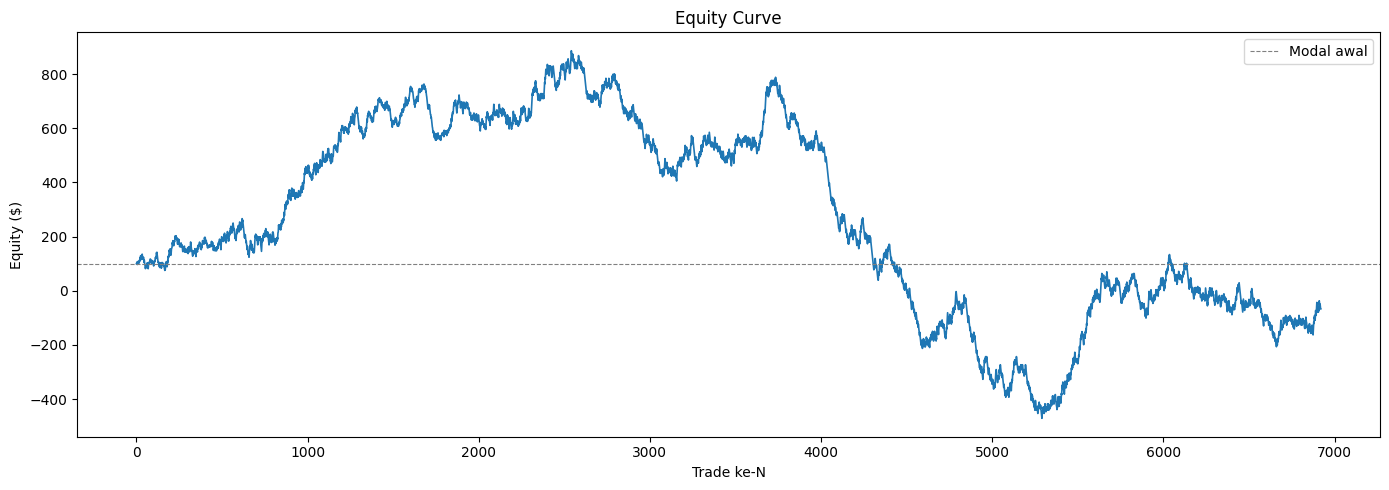

In [10]:
fig, ax = plt.subplots()
ax.plot(equity_curve, linewidth=1.2)
ax.axhline(INITIAL_EQUITY, color="gray", linestyle="--", linewidth=0.8, label="Modal awal")
ax.set_title("Equity Curve")
ax.set_xlabel("Trade ke-N")
ax.set_ylabel("Equity ($)")
ax.legend()
plt.tight_layout()
plt.savefig(EXPORT_DIR / "equity_curve.png", dpi=120)
plt.show()

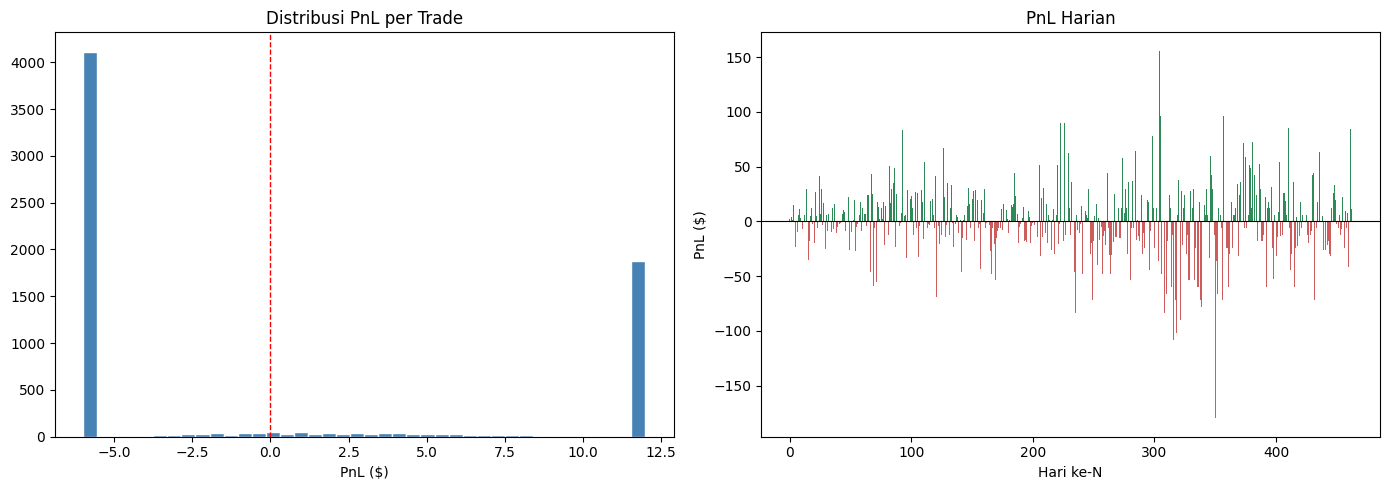

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(trades_df["pnl"], bins=40, color="steelblue", edgecolor="white")
axes[0].axvline(0, color="red", linestyle="--", linewidth=1)
axes[0].set_title("Distribusi PnL per Trade")
axes[0].set_xlabel("PnL ($)")

daily_pnl = trades_df.groupby(trades_df["entry_time"].dt.date)["pnl"].sum()
colors = ["seagreen" if v > 0 else "indianred" for v in daily_pnl.values]
axes[1].bar(range(len(daily_pnl)), daily_pnl.values, color=colors)
axes[1].axhline(0, color="black", linewidth=0.8)
axes[1].set_title("PnL Harian")
axes[1].set_xlabel("Hari ke-N")
axes[1].set_ylabel("PnL ($)")

plt.tight_layout()
plt.savefig(EXPORT_DIR / "pnl_distribution.png", dpi=120)
plt.show()

## 6. Simpan hasil

Dua level output:
- **`dataset/processed/m5_scalping/v02/trade_log_full.csv`** — log LENGKAP tiap trade + snapshot semua
  indikator saat entry (buat evaluasi mendalam: kondisi market seperti apa yg menghasilkan win/loss)
- **`dataset/exports/m5_scalping/v02/`** — ringkasan (trades.csv tanpa snapshot indikator, metrics.txt, grafik)

## 6. Evaluasi mendalam — pola indikator M5 & H1 di WIN vs LOSS

Bandingkan rata-rata tiap indikator kunci antara trade yang WIN dan LOSS, untuk cari petunjuk
kondisi market mana yang menguntungkan/merugikan. Ini dasar untuk tuning parameter di v03+.

In [12]:
key_indicators = [
    "ind_adx", "ind_atr", "ind_rsi", "ind_di_pos", "ind_di_neg",
    "ind_bull_chain", "ind_bear_chain",
    "ind_h1_adx", "ind_h1_rsi", "ind_h1_di_pos", "ind_h1_di_neg",
]

compare = trades_df.groupby("result")[key_indicators].mean().T
compare["diff"] = compare.get("WIN", 0) - compare.get("LOSS", 0)
compare

result,LOSS,WIN,diff
ind_adx,30.000038,29.279651,-0.720387
ind_atr,7.217523,6.227362,-0.990160
ind_rsi,49.223316,50.875065,1.651750
ind_di_pos,20.862525,21.762200,0.899675
ind_di_neg,23.657230,22.525363,-1.131867
ind_bull_chain,3.914071,4.088492,0.174421
ind_bear_chain,4.071835,3.890873,-0.180961
ind_h1_adx,28.669381,28.264917,-0.404464
ind_h1_rsi,50.442583,51.618569,1.175986
ind_h1_di_pos,20.332072,20.850408,0.518336


**Cek trend alignment M5 vs H1** — hipotesis: trade searah trend H1 (bukan melawan) harusnya win rate
lebih tinggi. `quant-trader-ai` pakai H1 sebagai filter/veto persis untuk alasan ini.

In [13]:
# Trend H1: EMA50 vs EMA200 (uptrend kalau EMA50 > EMA200)
trades_df["h1_trend"] = trades_df.apply(
    lambda r: "UP" if r["ind_h1_ema_50"] > r["ind_h1_ema_200"]
    else ("DOWN" if r["ind_h1_ema_50"] < r["ind_h1_ema_200"] else "FLAT"),
    axis=1,
)
trades_df["aligned_with_h1"] = (
    ((trades_df["direction"] == "BUY") & (trades_df["h1_trend"] == "UP"))
    | ((trades_df["direction"] == "SELL") & (trades_df["h1_trend"] == "DOWN"))
)

alignment_stats = trades_df.groupby("aligned_with_h1").agg(
    total_trades=("pnl", "count"),
    win_rate_pct=("result", lambda s: round((s == "WIN").mean() * 100, 2)),
    avg_pnl=("pnl", "mean"),
    net_pnl=("pnl", "sum"),
)
alignment_stats.index = alignment_stats.index.map({True: "Searah trend H1", False: "Melawan/netral trend H1"})
alignment_stats

,total_trades,win_rate_pct,avg_pnl,net_pnl
aligned_with_h1,,,,
Melawan/netral trend H1,3462,35.38,-0.157034,-543.651
Searah trend H1,3457,37.46,0.108884,376.412


**Win rate berdasarkan kekuatan signal_score** — kalau skor makin tinggi = win rate makin baik, itu
tanda scoring-nya ada isinya (bisa dinaikkan threshold). Kalau flat, artinya scoring belum informatif.

In [14]:
trades_df["abs_score_bucket"] = pd.cut(
    trades_df["signal_score"].abs(),
    bins=[6, 7, 8, 9, 10, 100],
    labels=["6-7", "7-8", "8-9", "9-10", "10+"],
)

score_stats = trades_df.groupby("abs_score_bucket", observed=True).agg(
    total_trades=("pnl", "count"),
    win_rate_pct=("result", lambda s: round((s == "WIN").mean() * 100, 2)),
    avg_pnl=("pnl", "mean"),
)
score_stats

,total_trades,win_rate_pct,avg_pnl
abs_score_bucket,,,
6-7,2166,35.13,-0.276799
7-8,1769,36.46,-0.074092
8-9,1242,35.51,-0.166715
9-10,838,38.31,0.344074
10+,847,38.49,0.531770


In [15]:
PROCESSED_OUT_DIR = PROJECT_ROOT / "dataset" / "processed" / STRATEGY_NAME / VERSION
PROCESSED_OUT_DIR.mkdir(parents=True, exist_ok=True)

# Log lengkap: semua kolom trade + snapshot indikator saat entry
trades_df.to_csv(PROCESSED_OUT_DIR / "trade_log_full.csv", index=False)

# Ringkasan tanpa snapshot indikator (buat quick view)
summary_cols = [c for c in trades_df.columns if not c.startswith("ind_")]
trades_df[summary_cols].to_csv(EXPORT_DIR / "trades.csv", index=False)

with open(EXPORT_DIR / "metrics.txt", "w") as f:
    f.write(f"Backtest v02 — XAUUSD M5 — periode {BACKTEST_START} s/d {df_bt['datetime'].max()}\n")
    f.write(f"Parameter: MIN_SIGNAL_SCORE={MIN_SIGNAL_SCORE}, ADX_MIN={ADX_MIN}, ATR_MIN_PCT={ATR_MIN_PCT}\n")
    f.write(f"TP={TP_POINTS} SL={SL_POINTS} RISK_PCT={RISK_PCT} MAX_HOLD={MAX_HOLD_CANDLES} candle\n\n")
    for k, v in metrics.items():
        f.write(f"{k}: {v}\n")

print("Log lengkap (trade + indikator):", PROCESSED_OUT_DIR / "trade_log_full.csv")
print("Ringkasan & grafik:", EXPORT_DIR)
for f in sorted(EXPORT_DIR.glob("*")):
    print(" -", f.name)

Log lengkap (trade + indikator): D:\Projects\robot-scalping\dataset\processed\m5_scalping\v02\trade_log_full.csv
Ringkasan & grafik: D:\Projects\robot-scalping\dataset\exports\m5_scalping\v02
 - equity_curve.png
 - metrics.txt
 - pnl_distribution.png
 - trades.csv
